# Trabajo Práctico 3 - Visión por Computadora

### Alumnos:
* BETTIG, Santiago Federico
* DIEGUEZ, Manuel

### Consigna
Encontrar el logotipo de la gaseosa dentro de las imágenes provistas a partir del template

In [305]:
# Importamos las bibliotecas que vamos a utilizar
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os
import supervision as sv

#### Parte 1
Obtener una detección del logo en cada imagen sin falsos positivos

Ancho: 400 Alto: 175
Se obtuvieron 211 descriptores del template


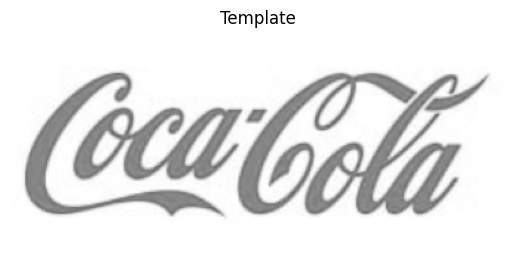

In [333]:
# Lo primero que hacemos es abrir nuestro template en 
# escala de grises
img_temp = cv.imread('template/pattern.png', cv.IMREAD_GRAYSCALE)

# Nos aseguramos de que se haya abierto correctamente
# plt.figure(figsize=(5, 3))
plt.imshow(cv.cvtColor(img_temp, cv.COLOR_BGR2RGB))
plt.title('Template')
plt.axis("off")

# Obtengo las dimensiones del template
w_temp, h_temp = img_temp.shape[::-1]

print(f"Ancho:", w_temp, "Alto:", h_temp)

# Creamos el vector de características SIFT del template
# y obtenemos los descriptores del template
sift = cv.SIFT_create()
kp_template, des_template = sift.detectAndCompute(img_temp,None)

print(f"Se obtuvieron", len(kp_template), "descriptores del template")

In [345]:
# Definimos la ruta en donde estarán las imágenes
img_path = './images/coca_logo_2.png'
img_i = cv.imread(img_path)
img_gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

# Obtengo las dimensiones de la imagen para poder comparar con el template
w_img, h_img = img_gray.shape[::-1]

# Obtenemos cual es la relación de tamaño entre el template y la imagen
# sobre la cual queremos buscar. 
# También definimos un paso en el cual iterar
w_rel = w_img/w_temp
h_rel = h_img/h_temp

step = 10
w_step = w_rel * (1/step)
h_step = h_rel * (1/step)

best_score = -1
best_loc = None
best_template_index = -1
best_template_shape = None

for i in range (step):
    w_scale = w_step*(i+1)
    for j in range (step):
        h_scale = h_step*(j+1)
        resized_temp = cv.resize(img_temp, None, fx=w_scale, fy=h_scale)
        img_i_match = cv.matchTemplate(img_gray, resized_temp, cv.TM_CCOEFF_NORMED)
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(img_i_match)

        # top_left = max_loc
        # # Marcamos el lugar donde lo haya encontrado
        # bottom_right = (top_left[0] + int(w_temp*w_scale), top_left[1] + int(h_temp*h_scale))
        # img_rgb = cv.cvtColor(img_i, cv.COLOR_BGR2RGB)
        # cv.rectangle(img_rgb, top_left, bottom_right, (0,255,0), 2)

        # # Resultado de coincidencia
        # plt.subplot(121),plt.imshow(resized_temp, cmap = 'gray')
        # plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
        # # Imagen original con recuadros
        # plt.subplot(122),plt.imshow(img_rgb)
        # plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
        # plt.show()

        if max_val > best_score:
            best_score = max_val
            best_loc = max_loc
            best_h_scale = h_scale
            best_w_scale = w_scale


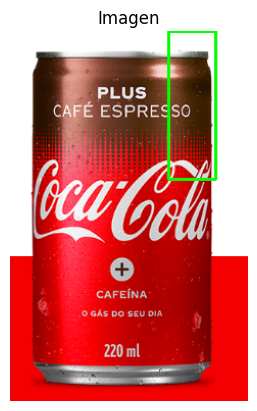

In [346]:
top_left = best_loc

# Marcamos el lugar donde lo haya encontrado
bottom_right = (top_left[0] + int(w_temp*best_w_scale), top_left[1] + int(h_temp*best_h_scale))

img_rgb = cv.cvtColor(img_i, cv.COLOR_BGR2RGB)
cv.rectangle(img_rgb, top_left, bottom_right, (0,255,0), 2)

plt.figure()
plt.imshow(img_rgb)
plt.title('Imagen')
plt.axis("off");